# 1. Import and load Data

## 1.1. Import neccessary libraries

In [1]:
# Import the libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from xgboost import XGBClassifier 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")

## 1.2. Import files and file configuration

In [2]:
# File paths
current_directory = "data"
chief_complaint_file_path = os.path.join(current_directory, "chief_complaints.csv")
patient_history_file_path = os.path.join(current_directory, "patient_history.csv")
sample_submission_file_path = os.path.join(current_directory, "sample_submission.csv")
train_file_path = os.path.join(current_directory, "train.csv")
test_file_path = os.path.join(current_directory, "test.csv")

In [3]:
IMG_PATH = os.path.join("data", "image")
if not os.path.exists(IMG_PATH):
    os.makedirs(IMG_PATH)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMG_PATH, f"{fig_id}.{fig_extension}")
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [4]:
# retrieve the data from each file to the vairablas
chief_complaint_data = pd.read_csv(chief_complaint_file_path) 
patient_history_data = pd.read_csv(patient_history_file_path)
train_data = pd.read_csv(train_file_path)
test_data = pd.read_csv(test_file_path)
sample_submission_data = pd.read_csv(sample_submission_file_path)

## Configure Environment for the training

In [5]:
# Predefined Variables for the project
SEED = 42
TARGET = "triage_acuity"
patient_id = "patient_id"

In [6]:
# Preconfig envrionment seed for reproducible result.
def seeder(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seeder(SEED)

In [7]:
# Preprocessing
# Merge data
train_data = train_data.merge(chief_complaint_data[['patient_id', 'chief_complaint_raw']], on='patient_id', how='left')
test_data = test_data.merge(chief_complaint_data[['patient_id', 'chief_complaint_raw']], on='patient_id', how='left')
train_data = train_data.merge(patient_history_data, on='patient_id', how='left')
test_data = test_data.merge(patient_history_data, on='patient_id', how='left')

# Add comorbidity_count
hx_cols = [col for col in train_data.columns if col.startswith('hx_')]
train_data['comorbidity_count'] = train_data[hx_cols].sum(axis=1)
test_data['comorbidity_count'] = test_data[hx_cols].sum(axis=1)

# Feature engineering
def add_clinical_flags(data):
    if 'systolic_bp' in data.columns:
        data['hypotensive'] = (data['systolic_bp'] < 90).astype(int)
    if 'heart_rate' in data.columns:
        data['tachycardic'] = (data['heart_rate'] > 100).astype(int)
    if 'temperature_c' in data.columns:
        data['febrile'] = (data['temperature_c'] > 38).astype(int)
    if 'spo2' in data.columns:
        data['hypoxic'] = (data['spo2'] < 92).astype(int)
    if 'age' in data.columns and 'hypotensive' in data.columns:
        data['elderly_hypotensive'] = ((data['age'] > 65) & (data['hypotensive'] == 1)).astype(int)

add_clinical_flags(train_data)
add_clinical_flags(test_data)

# Handle missing values
bp_cols = ['systolic_bp', 'diastolic_bp']
for col in bp_cols:
    if col in train_data.columns:
        median_val = train_data[col].median()
        train_data[col] = train_data[col].fillna(median_val)
        test_data[col] = test_data[col].fillna(median_val)

# Missing flags
key_vitals = ['systolic_bp', 'diastolic_bp', 'heart_rate', 'temperature_c', 'spo2', 'respiratory_rate']
for col in key_vitals:
    if col in train_data.columns:
        train_data[f'{col}_missing'] = train_data[col].isnull().astype(int)
        test_data[f'{col}_missing'] = test_data[col].isnull().astype(int)

# Impute numerical
numerical_cols = [col for col in train_data.select_dtypes(include=[np.number]).columns if col in test_data.columns and col != TARGET]
imputer = SimpleImputer(strategy='mean')
train_data[numerical_cols] = imputer.fit_transform(train_data[numerical_cols])
test_data[numerical_cols] = imputer.transform(test_data[numerical_cols])

# Remove leakage
leakage_cols = ['ed_los_hours', 'disposition']
X = train_data.drop(columns=[TARGET, 'patient_id'] + leakage_cols, errors='ignore')
y = train_data[TARGET]
X_test = test_data.drop(columns=[TARGET, 'patient_id'] + leakage_cols, errors='ignore')

# Encode categoricals
categorical_cols = [col for col in X.select_dtypes(include=['object']).columns if col in X_test.columns]
for col in categorical_cols:
    combined = pd.concat([X[col], X_test[col]], axis=0)
    le = LabelEncoder()
    le.fit(combined)
    X[col] = le.transform(X[col])
    X_test[col] = le.transform(X_test[col])

# Encode target
if y.dtype == 'object':
    target_le = LabelEncoder()
    y = target_le.fit_transform(y)

# Feature selection
selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X, y)
X_test_selected = selector.transform(X_test)

# SelectFromModel
rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
sfm = SelectFromModel(rf, threshold='median')
X_selected = sfm.fit_transform(X_selected, y)
X_test_selected = sfm.transform(X_test_selected)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
X_test_scaled = scaler.transform(X_test_selected)

# Split
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=SEED, stratify=y)

# Apply SMOTE
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Preprocessing complete")

Preprocessing complete


In [8]:
# Train models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {}

# Logistic Regression
lr = LogisticRegression(random_state=SEED, max_iter=1000)
lr.fit(X_train_resampled, y_train_resampled)
models['Logistic Regression'] = lr

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf.fit(X_train_resampled, y_train_resampled)
models['Random Forest'] = rf

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=SEED)
gb.fit(X_train_resampled, y_train_resampled)
models['Gradient Boosting'] = gb

print("Models trained")

Models trained


# 2. Data Analysis and Visualization

## 2.1. Overview the Data

In [38]:
# chief_complaint_data.head()
# patient_history_data.head()
# train_data.head()
# test_data.head()
sample_submission_data.head()

,patient_id,triage_acuity
0,TG-FZUFCRZS3,3
1,TG-SSCOXTYI1,3
2,TG-JY74ZR35D,3
3,TG-JDKD5G62X,3
4,TG-J1BSAAXR0,3


In [39]:
all_data = {
    "train":train_data,
    "test":test_data,
    "chief_complaint":chief_complaint_data,
    "pateint_his":patient_history_data,
    "sample_submission":sample_submission_data
}
for name,data in all_data.items():
    print(f"{name} column: {data.columns}")

for _,data in all_data.items():
     print(f"{data.shape}")

train column: Index(['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode',
       'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season',
       'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type',
       'transport_origin', 'pain_location', 'mental_status_triage',
       'chief_complaint_system', 'num_prior_ed_visits_12m',
       'num_prior_admissions_12m', 'num_active_medications',
       'num_comorbidities', 'systolic_bp', 'diastolic_bp',
       'mean_arterial_pressure', 'pulse_pressure', 'heart_rate',
       'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score',
       'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score',
       'disposition', 'ed_los_hours', 'triage_acuity'],
      dtype='object')
test column: Index(['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode',
       'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season',
       'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type',
       

In [12]:
# Col in test not in train
# ['disposition', 'ed_los_hours', 'triage_acuity']
print(train_data.shape)
print(test_data.shape)

(80000, 40)
(20000, 37)


In [13]:
train = train_data.merge(chief_complaint_data,on='patient_id',how='left')
train = train.merge(patient_history_data,on='patient_id',how='left')
test = test_data.merge(chief_complaint_data,on='patient_id',how='left')
test = test.merge(patient_history_data,on='patient_id',how='left')

                                        column  missing_count  \
systolic_bp                        systolic_bp           4146   
diastolic_bp                      diastolic_bp           4146   
mean_arterial_pressure  mean_arterial_pressure           4146   
pulse_pressure                  pulse_pressure           4146   
shock_index                        shock_index           4146   
respiratory_rate              respiratory_rate           3067   
temperature_c                    temperature_c            574   

                        missing_percentage  
systolic_bp                           5.18  
diastolic_bp                          5.18  
mean_arterial_pressure                5.18  
pulse_pressure                        5.18  
shock_index                           5.18  
respiratory_rate                      3.83  
temperature_c                         0.72  


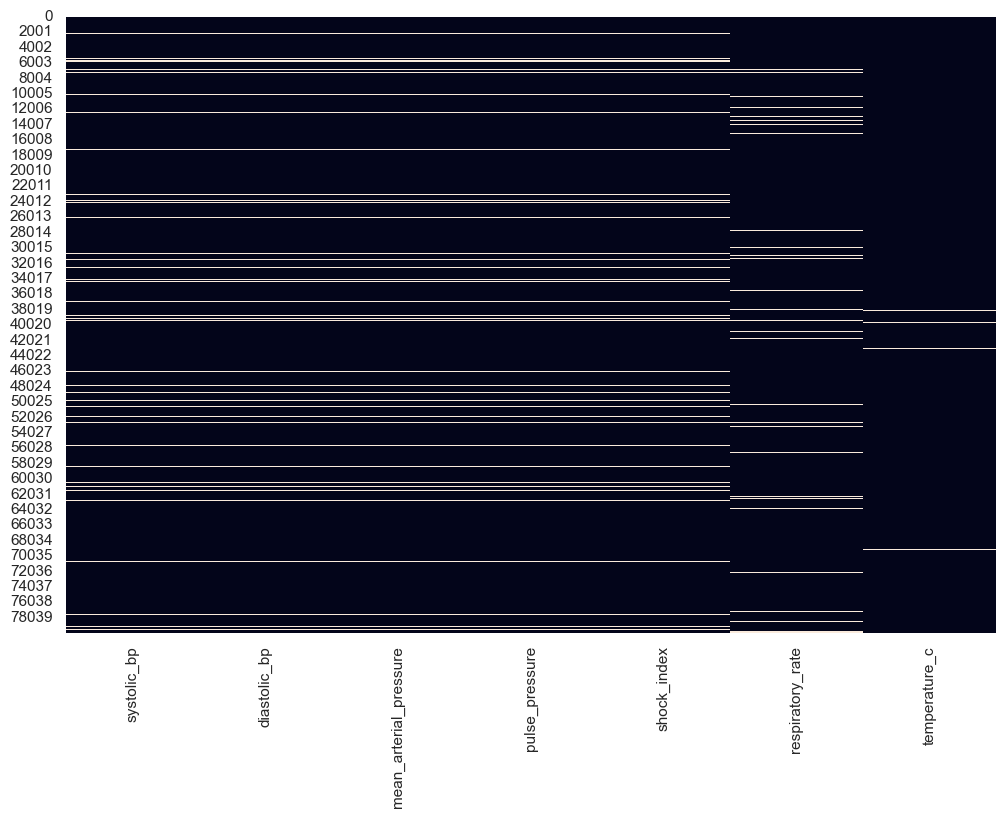

<Figure size 640x480 with 0 Axes>

In [14]:
from matplotlib.colors import ListedColormap
train_na = pd.DataFrame({
    'column': train.columns,
    'missing_count': train.isna().sum(),
    'missing_percentage': (train.isna().sum() * 100 /len(train)).round(2)
})
missing_data = train_na[train_na["missing_count"]>0].sort_values('missing_count',ascending= False)
print(missing_data)
plt.figure(figsize=(12,8))
sns.heatmap(train[missing_data['column']].isna(),cbar=False)
plt.show()
save_fig("missing_val_grouping")

In [15]:
train.iloc[78039]['systolic_bp']

np.float64(94.6)

Some of them are missing in groups. For example, systeolic_bp, diastolic_bp, mean_arterial_pressure, pulse_pressure,shock_index. This means that when the Blood Pressure is missing, all related BP info is also go missing.


In [16]:
# Create base clases needed to analyze the data of all datasets
# Can be the base class then sub classes including
# class for overview of data, class for plotting visual (line,bar,pie,...)
# class for normalization...
class DataAnalysis(ABC):
    def __init__(self,data):
        self.data = data
        self.result = {}

    def overview(self):
        return {
            
        }

In [17]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                80000 non-null  object 
 1   site_id                   80000 non-null  object 
 2   triage_nurse_id           80000 non-null  object 
 3   arrival_mode              80000 non-null  object 
 4   arrival_hour              80000 non-null  int64  
 5   arrival_day               80000 non-null  object 
 6   arrival_month             80000 non-null  int64  
 7   arrival_season            80000 non-null  object 
 8   shift                     80000 non-null  object 
 9   age                       80000 non-null  int64  
 10  age_group                 80000 non-null  object 
 11  sex                       80000 non-null  object 
 12  language                  80000 non-null  object 
 13  insurance_type            80000 non-null  object 
 14  transp

(24, 24)


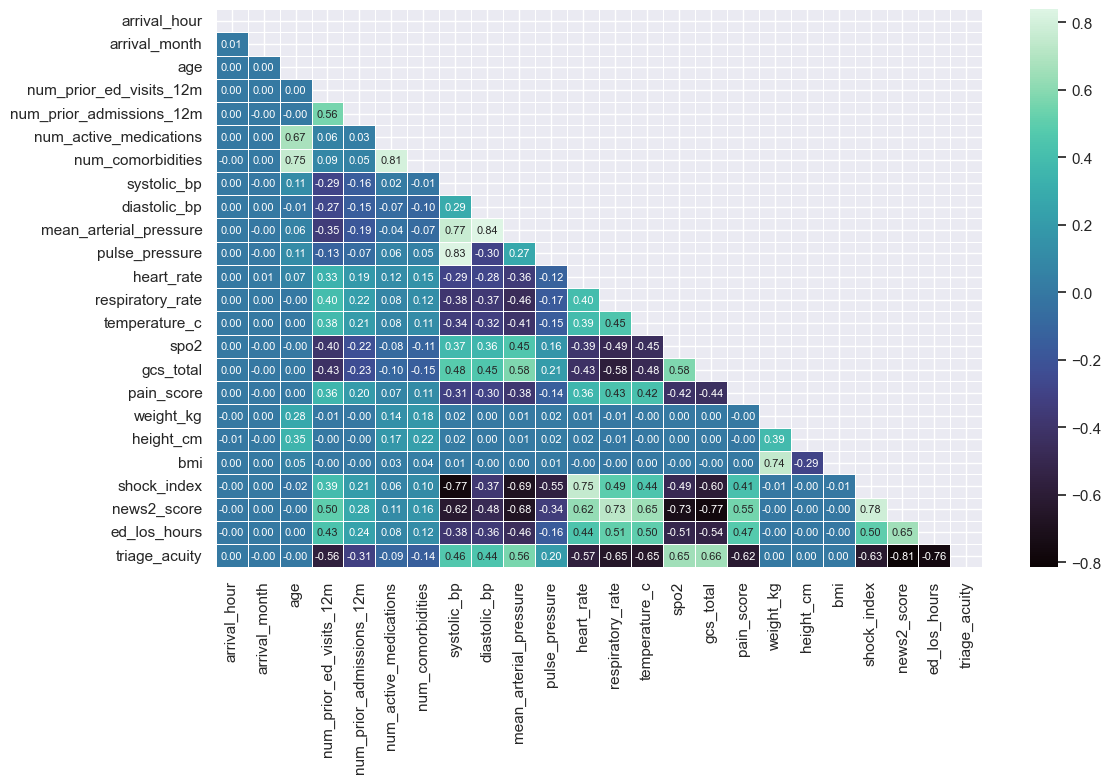

In [18]:
# train_no_obj = train_data.select_dtypes(exclude = "object")
corr_matrix = train_data.corr(numeric_only=True)
print(corr_matrix.shape)
mask = np.triu(np.ones_like(corr_matrix))
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,
            cmap="mako",
            mask = mask,
            annot = True,
            annot_kws={"size":8},
            fmt=".2f",
            linewidth=0.5)
save_fig("correlation_in_train_set")
plt.show()

 systeolic_bp, diastolic_bp, mean_arterial_pressure, pulse_pressure,shock_index.

In [19]:
corr_to_target = train_data.corr(numeric_only=True)[[TARGET]].sort_values(TARGET)
corr_to_target

,triage_acuity
news2_score,-0.814804
ed_los_hours,-0.756714
respiratory_rate,-0.652945
temperature_c,-0.649193
shock_index,-0.631830
pain_score,-0.618834
heart_rate,-0.567962
num_prior_ed_visits_12m,-0.564138
num_prior_admissions_12m,-0.311197
num_comorbidities,-0.142150


In [20]:
print(train_data[TARGET].value_counts())
print(train_data[TARGET].value_counts(normalize=True))
# Analyze categorical columns
categorical_cols = train_data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}: {train_data[col].nunique()} unique values")

triage_acuity
3    28921
4    23020
2    13439
5    11398
1     3222
Name: count, dtype: int64
triage_acuity
3    0.361513
4    0.287750
2    0.167988
5    0.142475
1    0.040275
Name: proportion, dtype: float64

patient_id: 80000 unique values

site_id: 5 unique values

triage_nurse_id: 50 unique values

arrival_mode: 6 unique values

arrival_day: 7 unique values

arrival_season: 4 unique values

shift: 4 unique values

age_group: 4 unique values

sex: 3 unique values

language: 8 unique values

insurance_type: 5 unique values

transport_origin: 7 unique values

pain_location: 9 unique values

mental_status_triage: 5 unique values

chief_complaint_system: 14 unique values

disposition: 7 unique values


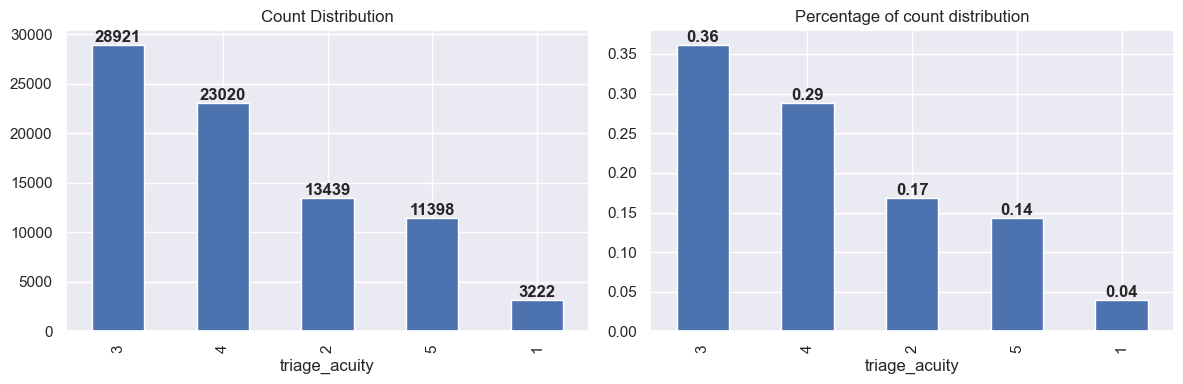

In [21]:
# Task 1.1
fig,axes = plt.subplots(1,2,figsize=(12,4),dpi=100)
Target_counts = train[TARGET].value_counts()
Target_counts.plot(kind= 'bar',ax=axes[0])
axes[0].set_title('Count Distribution')

for i,val in enumerate(Target_counts):
    axes[0].text(i,val,str(val),ha='center',va='bottom',fontweight = 'bold')
    
Target_Counts_Percentages = train[TARGET].value_counts(normalize = True)
Target_Counts_Percentages.plot(kind ='bar',ax= axes[1])
axes[1].set_title("Percentage of count distribution")
for i,val in enumerate(Target_Counts_Percentages):
    axes[1].text(i,val,f'{val:.2f}',ha='center',va='bottom',fontweight = 'bold')
plt.tight_layout()
plt.show()

from the figure, it appears that the difference is very consistent. from one class to another the gap is just 10% difference, suggesting unusual construction of dataset or a linear difference between classes.


It is also clear that majority of patient are not so severe when checking in with the most severe scales(1 and 2) are just 30% of all patients.

new2scores and ed_loss_hours shows unusually high relation with the target values.

In [22]:
def handle_categorical_data():
    pass

# Later become a class or a function

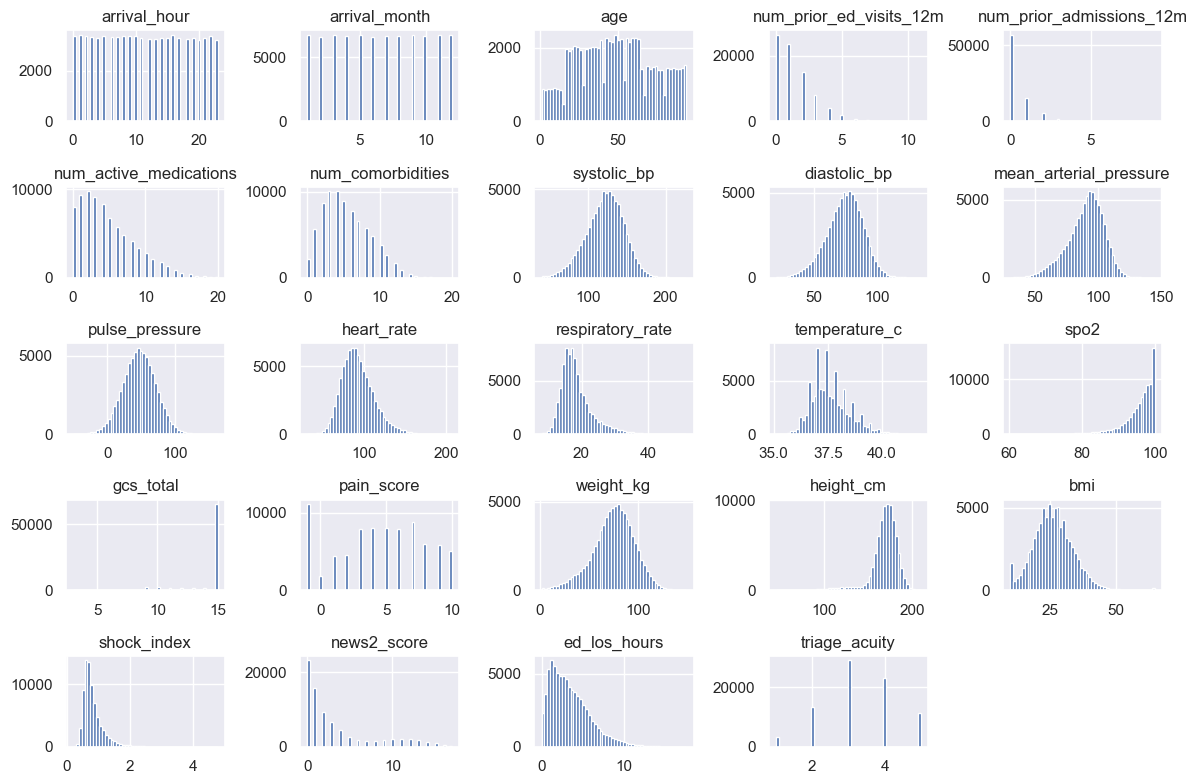

In [23]:
train_data.hist(bins=50,figsize=(12,8))
plt.tight_layout()

save_fig("Histogram_train_data")
plt.show()

#### Indivilual Insights:
_ Most patient are in late middle age when they visit the emergency department rooms.<br>
_ for ed_visits, it is heavily right-skewed (most 0-1 visits) but with a long tail of frequent users (≥3) who likely drive disproportionate resource use.<br>
_ ASdmission prior are mostly none, meaning the ER is about contact and decide whether to accept or reject, not preaprrove beforehand.<br>
_ Incoming patients don't have much active medications, meaning there is a lower risk of medical allegies or liver affection if we precribe more medications for them.<br>
_ Most patients have around 3-5 simultaneous complications or medical issues when entering the emergency rooms, suggesting complex medical condition for the patients. <br>
_ ed_los_hour: The data is right-skewed, meaning patients mostly spend less time in the emergency room department <br>

#### Group Insights:
_ For Vital group, the distribution is mostly at the normal range, but they habe different behoaviors. <br>
 BP parameters: Subsets with hypertension vs. hypotension suggest different presentations       (hypertensive urgency vs. sepsis)<br>
 HR/RR: Elevated tails capture pain, fever, or physiologic distress<br>
 Temperature: Mostly afebrile; febrile peak suggests infectious cases<br>
 SpO2: Left-skewed (95-100%); hypoxic tail (<92%) identifies critical res<br>iratory patients
 GCS: Overwhelmingly 15; <15 represents high-acuity altered mental status <br>
 Shock index/NEWS2: Low in most; elevated values strongly predict admission

To explore next:<br>
Old Age,mulitmobility,abnormal vitals, low visit + lowAcuity<br>
Frequent visits + low acuity<br>
Prolonged LOS + admission<br>
Normal vitals + low comorbidity + discharge

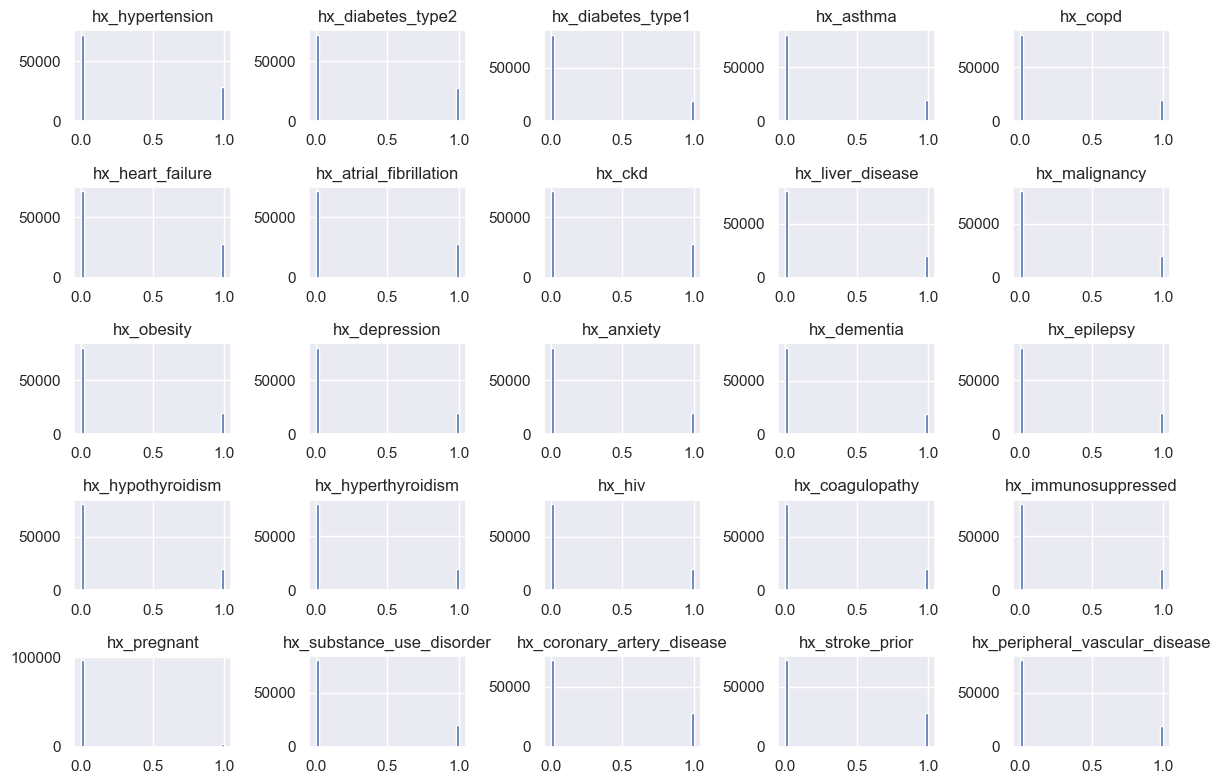

<Figure size 640x480 with 0 Axes>

In [24]:
patient_history_data.hist(bins = 50,figsize = (12,8))
plt.tight_layout()
plt.show()
save_fig("Histogram_patinet_his_data")

In [26]:
class TriageAnalysis:

    def __init__(self, dataframe):
        self.df = dataframe

    def show_heatmap(self):
        # Select condition columns only
        condition_columns = [col for col in self.df.columns if col != 'patient_id']

        plt.figure(figsize=(16, 12))
        sns.heatmap(self.df[condition_columns].corr(),
                    annot=True, cmap='coolwarm', fmt='.2f')
        plt.title('Correlation Between Medical Conditions')
        plt.show()

analysis = TriageAnalysis(train_data)
analysis.show_heatmap()
class MultiConditionAnalysis(TriageAnalysis):

    def show_condition_count(self):
        condition_columns = [col for col in self.df.columns if col != 'patient_id']

        # Count how many conditions each patient has
        self.df['total_conditions'] = self.df[condition_columns].sum(axis=1)

        print("Average conditions per patient:", self.df['total_conditions'].mean().round(2))
        print("Max conditions one patient has:", self.df['total_conditions'].max())

        plt.figure(figsize=(10, 5))
        sns.countplot(x='total_conditions', data=self.df, palette='Purples_d')
        plt.title('How Many Conditions Each Patient Has')
        plt.xlabel('Number of Conditions')
        plt.ylabel('Number of Patients')
        plt.show()

multi = MultiConditionAnalysis(train_data)
multi.show_condition_count()



ValueError: could not convert string to float: 'SITE-TMP-01'

<Figure size 1600x1200 with 0 Axes>

In [ ]:
class DataVisualization:
    # For the plotting of different graphs types such as line, bar,pie,etc.
    def __init__(self):
        pass

# 3.NLP for Text Preprocessing

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Load Data
df = pd.read_csv('/kaggle/input/competitions/triagegeist/chief_complaints.csv')

print("Shape:", df.shape)
print(df.head())

# 2. Lowercase + Clean the text (case-insensitive) 
df['complaint_clean'] = (
    df['chief_complaint_raw']
      .str.lower()                        # lowercase everything
      .str.replace(r'[^a-z\s]', ' ', regex=True)  # remove punctuation/symbols
      .str.strip()
)

# This will generate sample, just the top 5
print("\nSample cleaned text:")
print(df[['chief_complaint_raw', 'complaint_clean']].head(5))


# 3. TF-IDF Vectorizer 
tfidf = TfidfVectorizer(
    lowercase=True,          # enforce lowercase (redundant but safe)
    stop_words='english',    # remove common stop words (with, and, the...)
    ngram_range=(1, 2),      # unigrams + bigrams e.g. "chest pain" as one token
    min_df=1,                # include words that appear at least once
    max_features=500         # top 500 most relevant terms
)

tfidf_matrix = tfidf.fit_transform(df['complaint_clean'])

# 4. View All Extracted Tokens 
feature_names = tfidf.get_feature_names_out()
print(f"\nTotal unique tokens extracted: {len(feature_names)}")
print("Sample tokens:", feature_names[:30])

# 5. TF-IDF uses for (averaged score of each across all docs) 
import numpy as np

tfidf_scores = tfidf_matrix.toarray().mean(axis=0)
token_df = pd.DataFrame({
    'token': feature_names,
    'tfidf_score': tfidf_scores
}).sort_values('tfidf_score', ascending=False)

print("\nTop 20 most significant tokens:")
print(token_df.head(20))

# 6. ESI Word Dictionary (Score 1=most dangerous → 5=least) 
ESI_WORD_DICT = {

    # ── ESI LEVEL 1 — IMMEDIATE / LIFE THREATENING ──────────────────────────
    # Patient may die without instant intervention
    "cardiac arrest":           1,
    "respiratory arrest":       1,
    "pulseless electrical":     1,
    "ventricular fibrillation": 1,
    "asthmaticus unresponsive": 1,
    "status epilepticus":       1,
    "epilepticus refractory":   1,
    "coma unknown":             1,
    "hypothyroid coma":         1,
    "collapse unresponsive":    1,
    "mva unresponsive":         1,
    "hypoglycaemia unresponsive":1,
    "unresponsive":             1,
    "cardiac":                  1,
    "arrest":                   1,
    "drowning":                 1,
    "near drowning":            1,
    "gunshot wound":            1,
    "traumatic amputation":     1,
    "traumatic brain":          1,
    "massive transfusion":      1,
    "tension pneumothorax":     1,
    "airway obstruction":       1,
    "airway compromise":        1,
    "locked syndrome":          1,
    "pulseless":                1,
    "fulminant hepatic":        1,
    "fulminant hepatitis":      1,

    # ── ESI LEVEL 2 — EMERGENT / HIGH RISK ──────────────────────────────────
    # High risk of deterioration, needs fast workup
    "acute stemi":              2,
    "acute nstemi":             2,
    "nstemi":                   2,
    "stemi cardiogenic":        2,
    "aortic dissection":        2,
    "aortic aneurysm":          2,
    "ruptured aortic":          2,
    "ruptured ectopic":         2,
    "ectopic pregnancy":        2,
    "acute stroke":             2,
    "ischaemic stroke":         2,
    "massive ischaemic":        2,
    "stroke herniation":        2,
    "herniation signs":         2,
    "meningococcal septicaemia":2,
    "meningococcal purpura":    2,
    "bacterial meningitis":     2,
    "meningitis suspected":     2,
    "septic shock":             2,
    "cardiogenic shock":        2,
    "toxic shock":              2,
    "anaphylaxis bronchospasm": 2,
    "anaphylaxis urticaria":    2,
    "anaphylaxis":              2,
    "severe anaphylaxis":       2,
    "severe allergic":          2,
    "hypertensive emergency":   2,
    "severe hypertensive":      2,
    "acute adrenal":            2,
    "adrenal crisis":           2,
    "adrenal insufficiency":    2,
    "diabetic ketoacidosis":    2,
    "dka":                      2,
    "hyperosmolar hyperglycaemic": 2,
    "hyperglycaemic crisis":    2,
    "suicidal ideation":        2,
    "suicidal attempt":         2,
    "active suicidal":          2,
    "ideation plan":            2,
    "attempt ongoing":          2,
    "self harm haemorrhage":    2,
    "severe self":              2,
    "acute psychosis":          2,
    "excited delirium":         2,
    "psychosis violence":       2,
    "altered mental":           2,
    "acute altered":            2,
    "sepsis altered":           2,
    "confusion elderly":        2,
    "haemodynamically unstable":2,
    "haemodynamic instability": 2,
    "uncontrolled haemodynamic":2,
    "haemodynamic compromise":  2,
    "gi haemorrhage":           2,
    "haematemesis":             2,
    "bleed haematemesis":       2,
    "vomiting blood":           2,
    "actively bleeding":        2,
    "massive lower":            2,
    "massive pulmonary":        2,
    "large pulmonary":          2,
    "pulmonary embolism":       2,
    "testicular torsion":       2,
    "ovarian torsion":          2,
    "torsion shock":            2,
    "globe rupture":            2,
    "retinal detachment":       2,
    "central retinal":          2,
    "retinal artery":           2,
    "acute angle":              2,
    "angle closure":            2,
    "severe acute":             2,
    "severe cardiogenic":       2,
    "acute mastoiditis":        2,
    "epiglottitis suspected":   2,
    "retropharyngeal abscess":  2,
    "peritonsillar abscess":    2,
    "abscess airway":           2,
    "abscess trismus":          2,
    "necrotising fasciitis":    2,
    "necrotising infection":    2,
    "fasciitis rapid":          2,
    "rapidly spreading":        2,
    "rapid spread":             2,
    "compartment syndrome":     2,
    "orbital compartment":      2,
    "spinal cord":              2,
    "cord injury":              2,
    "open fracture":            2,
    "fracture haemodynamically":2,
    "pelvic fracture":          2,
    "femur fracture":           2,
    "open femur":               2,
    "multi trauma":             2,
    "blunt thoracic":           2,
    "penetrating abdominal":    2,
    "penetrating neck":         2,
    "fractures airway":         2,
    "multi organ":              2,
    "organ failure":            2,
    "organ dysfunction":        2,
    "failure hypoxia":          2,
    "respiratory failure":      2,
    "renal failure":            2,
    "hepatic failure":          2,
    "heart failure":            2,
    "decompensated heart":      2,
    "severe dyspnoea":          2,
    "dyspnoea rest":            2,
    "severe pain":              2,
    "syncope":                  2,
    "near syncope":             2,
    "collapse":                 2,
    "thyroid storm":            2,
    "acute mania":              2,
    "mania risk":               2,
    "alcohol withdrawal":       2,
    "drug overdose":            2,
    "deliberate overdose":      2,
    "overdose collapse":        2,
    "overdose unknown":         2,
    "severe malaria":           2,
    "stevens johnson":          2,
    "toxic epidermal":          2,
    "epidermal necrolysis":     2,
    "bullous pemphigoid":       2,
    "pemphigoid acute":         2,
    "eczema herpeticum":        2,
    "status asthmaticus":       2,
    "severe asthma":            2,
    "mesenteric ischaemia":     2,
    "acute mesenteric":         2,
    "bowel perforation":        2,
    "perforation peritonitis":  2,
    "priapism ischaemia":       2,
    "urosepsis":                2,

    # ── ESI LEVEL 3 — URGENT ────────────────────────────────────────────────
    # Stable but needs multiple resources / monitoring
    "chest pain":               3,
    "pleuritic chest":          3,
    "exertional chest":         3,
    "chest discomfort":         3,
    "chest tightness":          3,
    "atrial fibrillation":      3,
    "af stable":                3,
    "palpitations":             3,
    "dyspnoea exertion":        3,
    "dyspnoea":                 3,
    "shortness":                3,
    "tightness dyspnoea":       3,
    "abdominal pain":           3,
    "acute abdomen":            3,
    "blunt abdominal":          3,
    "abdominal stab":           3,
    "abdominal cramping":       3,
    "appendicitis":             3,
    "renal colic":              3,
    "flank pain":               3,
    "stab wound":               3,
    "fracture":                 3,
    "bone fracture":            3,
    "rib fracture":             3,
    "ankle fracture":           3,
    "radius fracture":          3,
    "distal radius":            3,
    "closed ankle":             3,
    "fall height":              3,
    "fall injury":              3,
    "head injury":              3,
    "significant head":         3,
    "significant mechanism":    3,
    "high speed":               3,
    "injury gcs":               3,
    "injury neurological":      3,
    "neurological deficit":     3,
    "focal deficits":           3,
    "focal":                    3,
    "limb weakness":            3,
    "transient limb":           3,
    "facial droop":             3,
    "droop resolved":           3,
    "seizure":                  3,
    "ongoing seizure":          3,
    "sepsis":                   3,
    "sepsis signs":             3,
    "wound sepsis":             3,
    "severe fever":             3,
    "high fever":               3,
    "fever unknown":            3,
    "dengue fever":             3,
    "dengue":                   3,
    "malaria":                  3,
    "pancreatitis":             3,
    "acute pancreatitis":       3,
    "pancreatitis organ":       3,
    "cellulitis systemic":      3,
    "orbital cellulitis":       3,
    "spreading cellulitis":     3,
    "infected wound":           3,
    "wound infection":          3,
    "laceration actively":      3,
    "scalp laceration":         3,
    "facial laceration":        3,
    "deep dog":                 3,
    "dog bite":                 3,
    "bite wound":               3,
    "significant blunt":        3,
    "thoracic trauma":          3,
    "neck trauma":              3,
    "facial trauma":            3,
    "trauma haemothorax":       3,
    "haemothorax":              3,
    "pneumothorax":             3,
    "haemoptysis significant":  3,
    "haematuria significant":   3,
    "bloody diarrhoea":         3,
    "gi bleed":                 3,
    "upper gi":                 3,
    "lower gi":                 3,
    "diarrhoea":                3,
    "vomiting":                 3,
    "bilious vomiting":         3,
    "nausea vomiting":          3,
    "dehydration moderate":     3,
    "severe dehydration":       3,
    "headache":                 3,
    "thunderclap headache":     3,
    "thunderclap":              3,
    "migraine photophobia":     3,
    "migraine":                 3,
    "acute vertigo":            3,
    "vertigo vomiting":         3,
    "dizziness":                3,
    "positional dizziness":     3,
    "confusion":                3,
    "delirium":                 3,
    "obtundation":              3,
    "hypoglycaemia":            3,
    "severe hypoglycaemia":     3,
    "hyperglycaemia":           3,
    "electrolyte disturbance":  3,
    "electrolyte imbalance":    3,
    "abnormal vitals":          3,
    "hypothermia moderate":     3,
    "hypothermia":              3,
    "hypoxia":                  3,
    "dysphagia":                3,
    "severe tonsillitis":       3,
    "tonsillitis dysphagia":    3,
    "peritonitis":              3,
    "pyelonephritis fever":     3,
    "pyelonephritis":           3,
    "urinary retention":        3,
    "acute urinary":            3,
    "vaginal bleeding":         3,
    "ectopic":                  3,
    "psychiatric decompensation":3,
    "acute psychiatric":        3,
    "substance intoxication":   3,
    "intoxication":             3,
    "overdose":                 3,
    "self harm":                3,
    "severe self":              3,
    "pain":                     3,
    "severe pain":              3,
    "scrotal pain":             3,
    "worsening":                3,
    "worsening hours":          3,
    "rigors":                   3,
    "diaphoresis":              3,
    "diaphoresis arm":          3,
    "bleeding":                 3,
    "haemorrhage":              3,
    "infection":                3,
    "fever":                    3,
    "nausea":                   3,
    "shingles":                 3,
    "shingles pain":            3,
    "erythema migrans":         3,
    "cellulitis":               3,
    "wound":                    3,
    "laceration":               3,
    "trauma":                   3,

    # ── ESI LEVEL 4 — LESS URGENT ───────────────────────────────────────────
    # One resource needed, stable condition
    "moderate headache":        4,
    "chronic headache":         4,
    "headache review":          4,
    "migraine recurrence":      4,
    "mild nausea":              4,
    "mild fever":               4,
    "mild dyspnoea":            4,
    "mild dysuria":             4,
    "mild abdominal":           4,
    "mild bloating":            4,
    "mild chest":               4,
    "mild confusion":           4,
    "mild dehydration":         4,
    "mild epistaxis":           4,
    "mild hypoglycaemia":       4,
    "mild gastroenteritis":     4,
    "mild wheeze":              4,
    "mild urinary":             4,
    "moderate epistaxis":       4,
    "epistaxis controlled":     4,
    "epistaxis":                4,
    "rash":                     4,
    "allergic rash":            4,
    "skin rash":                4,
    "contact dermatitis":       4,
    "dermatitis":               4,
    "urticaria":                4,
    "eczema":                   4,
    "conjunctivitis":           4,
    "corneal abrasion":         4,
    "eye irritation":           4,
    "itchy eyes":               4,
    "mild eye":                 4,
    "mild photophobia":         4,
    "mild sore":                4,
    "sore throat":              4,
    "throat moderate":          4,
    "tonsillitis":              4,
    "otitis media":             4,
    "ear pain":                 4,
    "sinusitis":                4,
    "productive cough":         4,
    "cough":                    4,
    "chronic cough":            4,
    "nasal congestion":         4,
    "congestion runny":         4,
    "runny nose":               4,
    "urti mild":                4,
    "viral urti":               4,
    "ankle sprain":             4,
    "lateral ankle":            4,
    "knee injury":              4,
    "shoulder pain":            4,
    "shoulder dislocation":     4,
    "muscle strain":            4,
    "muscle soreness":          4,
    "sprain":                   4,
    "bruised knee":             4,
    "minor abrasion":           4,
    "abrasion":                 4,
    "minor facial":             4,
    "minor head":               4,
    "minor wound":              4,
    "minor skin":               4,
    "small cut":                4,
    "cut wound":                4,
    "superficial laceration":   4,
    "minor joint":              4,
    "joint ache":               4,
    "swollen joint":            4,
    "hot swollen":              4,
    "dysuria":                  4,
    "dysuria systemic":         4,
    "uncomplicated uti":        4,
    "uti symptoms":             4,
    "uti":                      4,
    "urinary symptoms":         4,
    "genital discharge":        4,
    "mild":                     4,
    "minor":                    4,
    "low grade":                4,
    "afebrile":                 4,
    "tick bite":                4,
    "insect bite":              4,
    "insect sting":             4,
    "ingrown toenail":          4,
    "toenail infected":         4,
    "skin tag":                 4,
    "splinter removal":         4,
    "acne":                     4,
    "sunburn":                  4,
    "dry skin":                 4,
    "bloating":                 4,
    "constipation":             4,
    "ibs":                      4,
    "chronic flare":            4,
    "anxiety flare":            4,
    "panic attack":             4,
    "low mood":                 4,
    "depressive episode":       4,
    "chronic anxiety":          4,
    "insomnia severe":          4,
    "fatigue":                  4,
    "weight loss":              4,
    "hearing loss":             4,
    "blocked ear":              4,
    "ear wax":                  4,
    "wax removal":              4,
    "pelvic":                   4,
    "vaginal":                  4,
    "contraception":            4,

    # ── ESI LEVEL 5 — NON-URGENT ────────────────────────────────────────────
    # No resources needed, admin or routine queries
    "prescription refill":      5,
    "antihypertensive refill":  5,
    "repeat prescription":      5,
    "refill request":           5,
    "refill":                   5,
    "glasses prescription":     5,
    "drop prescription":        5,
    "medical certificate":      5,
    "certificate request":      5,
    "cardiology paperwork":     5,
    "paperwork":                5,
    "routine check":            5,
    "routine bp":               5,
    "routine sti":              5,
    "bp monitoring":            5,
    "blood pressure":           5,
    "glucose monitoring":       5,
    "blood glucose":            5,
    "general health":           5,
    "general unwell":           5,
    "health question":          5,
    "health medication":        5,
    "management question":      5,
    "diabetes review":          5,
    "diabetes management":      5,
    "medication review":        5,
    "medication adjustment":    5,
    "medication effect":        5,
    "thyroid medication":       5,
    "thyroid related":          5,
    "follow":                   5,
    "stable follow":            5,
    "ibs follow":               5,
    "non urgent":               5,
    "advice":                   5,
    "contraception advice":     5,
    "dietary advice":           5,
    "activity advice":          5,
    "acne advice":              5,
    "hygiene advice":           5,
    "sleep hygiene":            5,
    "exposure advice":          5,
    "travel prophylaxis":       5,
    "post exposure":            5,
    "vaccination":              5,
    "sti screening":            5,
    "screening":                5,
    "referral query":           5,
    "counselling referral":     5,
    "physiotherapy referral":   5,
    "endocrine referral":       5,
    "administrative query":     5,
    "admission query":          5,
    "adjustment query":         5,
    "social admission":         5,
    "prescription query":       5,
    "prescription question":    5,
    "result inquiry":           5,
    "ecg result":               5,
    "memory complaint":         5,
    "non specific":             5,
    "intermittent":             5,
    "check":                    5,
    "wound check":              5,
    "suture removal":           5,
    "tag removal":              5,
    "removal request":          5,
    "splinter":                 5,
}

ESI_LABELS = {
    1: "Immediate",
    2: "Emergent",
    3: "Urgent",
    4: "Less Urgent",
    5: "Non-Urgent"
}

# 7. Map ESI Score to Each Token 
def get_esi_score(token):
    if token in ESI_WORD_DICT:
        return ESI_WORD_DICT[token]
    for key, score in ESI_WORD_DICT.items():
        if key in token or token in key: 
            return score
    return None   # unscored word

# This is where it map to the esi score level
token_df['esi_score'] = token_df['token'].apply(get_esi_score)
token_df['esi_label'] = token_df['esi_score'].map(ESI_LABELS)

scored_df = token_df.dropna(subset=['esi_score']).copy()
scored_df['esi_score'] = scored_df['esi_score'].astype(int)

scored_df = scored_df.sort_values(['esi_score', 'tfidf_score'], ascending=[True, False])

print("\nESI-scored tokens:\n")
print(scored_df[['token', 'tfidf_score', 'esi_score', 'esi_label']].to_string(index=False))

# ── 8. Assign ESI Level per Patient ──────────────────────────────────────────
def assign_patient_with_esi(text):
    tokens = text.lower().split()
    min_esi = 5
    for token in tokens:
        score = get_esi_score(token)
        if score is not None and score < min_esi:
            min_esi = score
    # also check bigrams
        # unigram is for one  word
        # bigram is for two words
    words = text.lower().split()
    for i in range(len(words) - 1):
        bigram = words[i] + " " + words[i+1]
        score = get_esi_score(bigram)
        if score < min_esi and score is not None:
            min_esi = score
    return min_esi

df['esi_level']  = df['complaint_clean'].apply(assign_patient_with_esi)
df['esi_label']  = df['esi_level'].map(ESI_LABELS)

print("\n===Patient ESI assignments:===")
print(df[['patient_id', 'complaint_clean', 'esi_level', 'esi_label']].to_string(index=False))

# ── 9. Save Output ────────────────────────────────────────────────────────────
df.to_csv('esi_scored_patients.csv', index=False)
scored_df.to_csv('esi_scored_tokens.csv', index=False)

print("\n✅ Saved: esi_scored_patients.csv & esi_scored_tokens.csv")

# 4. Machine Learning

In [ ]:
# For the machine learning class later when we try to integrate it.
class Tansformer(ABC):
    def __init__(self,name):
        self.name = name
        self.is_fitted = False
    @abstractmethod
    def fit(self,X):
        pass
    @abstractmethod
    def transfrom(self,X):
        pass
    @abstractmethod
    def fit_transform(self,X):
        pass
        
    def __str__(self):
        status = "Fitted" if self.isfitted else "Not fitted"
        return f"{self.name} is {status}"
    def __call__(self,X):
        return self.transfrom(X)
    

In [ ]:
class BaseModel(ABC):
    def __init__(self,name):
        self.name = name
        self.is_trained = False
        self.metadata = {}
        self.feature_importance = None
        self.model = None

    # May also include running time in here....
    @abstractmethod
    def fit(self,X,Y):
        pass
    @abstractmethod
    def predict(self,X):
        pass
    @abstractmethod
    def probability(self,X):
        pass

    def __repr__(self):
        return f"{self.name} {self.is_trained}"
    def __str__(self):
        status = "trained" if self.is_trained else "not trained"
        return f"{self.name} is {status}"
    def __call__(self,X):
        return self.predict(X)
    def __getitem__(self,key,value):
        return self.metadata.get(key)
    def __setitem__(self,key,value):
        return self.metadata[key]==value
    def __len__(self):
        return len(self.metadata)

In [ ]:
class logistic_regression(BaseModel):
    def __init__(self,name="Logistic Regression"):
        super().__init__(name)
        self.model = LogisticRegressionModel(max_iter = 1000, random_state = SEED)
    def __fit__(self,X,y):
        self.is_trained = True

In [ ]:
class RandomForest(BaseModel):
    def __init__(self,name=""):
        super().__init__(name)
        # self.model = LogisticRegressionModel(max_iter = 1000, random_state = SEED)
        

In [ ]:
class XGBoost(BaseModel):
    def __init__(self,name="XGBoost"):
        super().__init__(name)
        # self.model = LogisticRegressionModel(max_iter = 1000, random_state = SEED)        

In [ ]:
class ModelEval():
    pass


In [ ]:
class FineTune():
    pass

In [ ]:
# Export model

In [ ]:
#Todo:
# _ Implement the preprocessing pipelines for all type of data (Numeric,categorical,
# text) then combine them into another pipeline 
# _ Implement the child classes of each ML algorithm.
# _ Pipelines
# _ Evaluate models

# _ Esemble Learning (Optional) 
# 

# Data Science Pipeline

## 1. DATA LOADING

In [27]:
# Load the dataset (assuming train_data is already loaded)
print("Shape of train_data:", train_data.shape)
print("\nColumns:", list(train_data.columns))
print("\nData types:")
print(train_data.dtypes)
print("\nMissing values:")
print(train_data.isnull().sum())
print("\nBasic statistics:")
print(train_data.describe())

Shape of train_data: (80000, 40)

Columns: ['patient_id', 'site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season', 'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage', 'chief_complaint_system', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications', 'num_comorbidities', 'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure', 'pulse_pressure', 'heart_rate', 'respiratory_rate', 'temperature_c', 'spo2', 'gcs_total', 'pain_score', 'weight_kg', 'height_cm', 'bmi', 'shock_index', 'news2_score', 'disposition', 'ed_los_hours', 'triage_acuity']

Data types:
patient_id                   object
site_id                      object
triage_nurse_id              object
arrival_mode                 object
arrival_hour                  int64
arrival_day                  object
arrival_month                 int64
arrival_season               object
sh

## 2. EXPLORATORY DATA ANALYSIS (EDA)

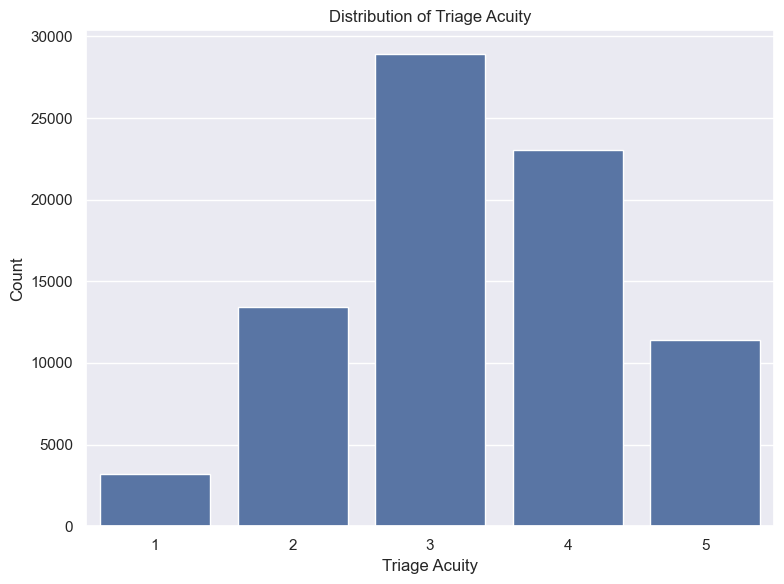

In [28]:
# Target distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=TARGET, data=train_data)
plt.title('Distribution of Triage Acuity')
plt.xlabel('Triage Acuity')
plt.ylabel('Count')
save_fig('target_distribution')
plt.show()

# Insight: The target variable shows the distribution of triage levels, indicating class imbalance if some levels are more frequent.

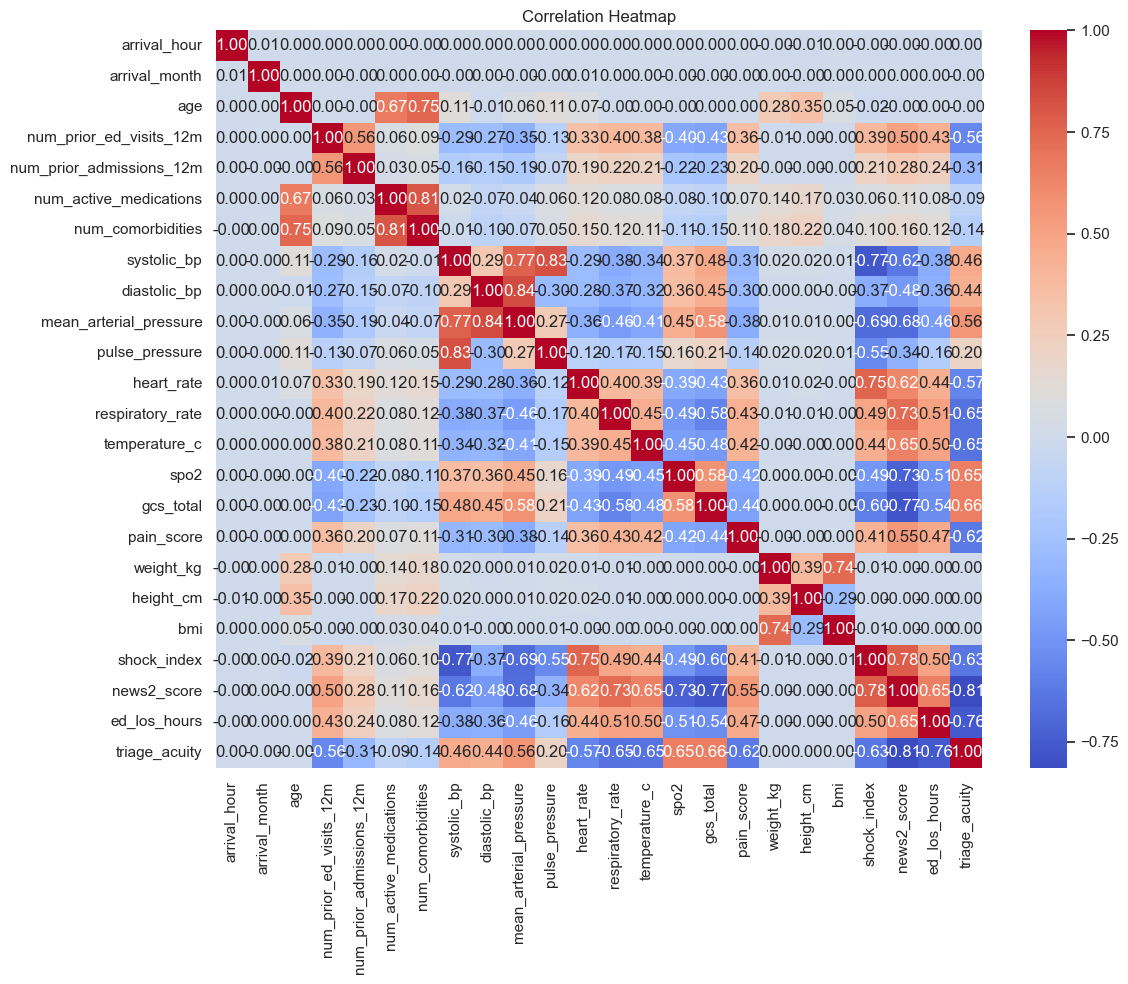

In [29]:
# Correlation heatmap for numerical features
numerical_cols = train_data.select_dtypes(include=[np.number]).columns
corr_matrix = train_data[numerical_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
save_fig('correlation_heatmap')
plt.show()

# Insight: The heatmap shows correlations between numerical features, helping identify multicollinearity.

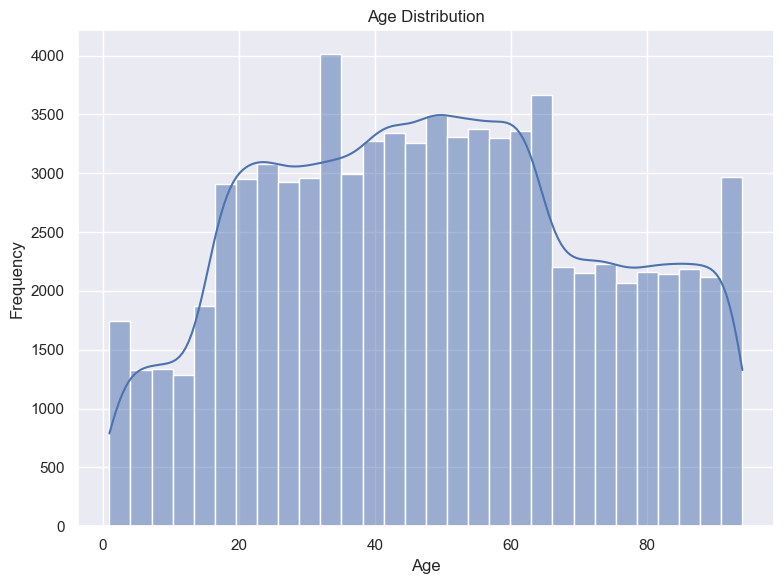

In [30]:
# Distribution of a categorical feature, e.g., gender if exists
if 'gender' in train_data.columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x='gender', data=train_data)
    plt.title('Gender Distribution')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    save_fig('gender_distribution')
    plt.show()
    # Insight: Shows the gender distribution in the dataset.

# Histogram for age
if 'age' in train_data.columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(train_data['age'], bins=30, kde=True)
    plt.title('Age Distribution')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    save_fig('age_distribution')
    plt.show()
    # Insight: The age distribution indicates the age range of patients, useful for understanding demographics.

## 4. IMPORTANT INSIGHTS SUMMARY

## Additional Visualizations

In [ ]:
# Box plots for feature-target relationships
numerical_features = train_data.select_dtypes(include=[np.number]).columns[:5]  # First 5 numerical features
for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=TARGET, y=feature, data=train_data)
    plt.title(f'Boxplot of {feature} by {TARGET}')
    save_fig(f'boxplot_{feature}')
    plt.show()
    print(f"Insight: {feature} shows variation across triage levels, indicating potential predictive power.")

In [ ]:
# Missing value correlation heatmap
missing_corr = train_data.isnull().corr()
plt.figure(figsize=(12, 10))
sns.heatmap(missing_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Missing Value Correlation Heatmap')
save_fig('missing_correlation')
plt.show()
print("Insight: High correlations between missing values may indicate systematic missingness, requiring careful imputation.")

## 3. TEXT PROCESSING

In [41]:
# Merge chief_complaints.csv with train/test data
# Assuming chief_complaint_data has 'patient_id' and 'chief_complaint_raw'
train_data = train_data.merge(chief_complaint_data[['patient_id', 'chief_complaint_raw']], on='patient_id', how='left')
test_data = test_data.merge(chief_complaint_data[['patient_id', 'chief_complaint_raw']], on='patient_id', how='left')

# Apply TF-IDF to chief complaint text
tfidf = TfidfVectorizer(max_features=100, stop_words='english')
train_tfidf = tfidf.fit_transform(train_data['chief_complaint_raw'].fillna(''))
test_tfidf = tfidf.transform(test_data['chief_complaint_raw'].fillna(''))

# Convert to DataFrame and add to dataset
tfidf_cols = [f'tfidf_{i}' for i in range(100)]
train_tfidf_df = pd.DataFrame(train_tfidf.toarray(), columns=tfidf_cols, index=train_data.index)
test_tfidf_df = pd.DataFrame(test_tfidf.toarray(), columns=tfidf_cols, index=test_data.index)

train_data = pd.concat([train_data, train_tfidf_df], axis=1)
test_data = pd.concat([test_data, test_tfidf_df], axis=1)

print("TF-IDF features added. Train shape:", train_data.shape, "Test shape:", test_data.shape)

TF-IDF features added. Train shape: (80000, 141) Test shape: (20000, 138)


In [40]:
print("Chief complaint columns:", chief_complaint_data.columns.tolist())

Chief complaint columns: ['patient_id', 'chief_complaint_raw', 'chief_complaint_system']


## 5. MACHINE LEARNING PREPARATION

In [ ]:
# Feature selection
from sklearn.feature_selection import SelectFromModel
selector = SelectKBest(score_func=f_classif, k=50)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()].tolist()

# SelectFromModel for TF-IDF features
rf_temp = RandomForestClassifier(n_estimators=100, random_state=SEED)
sfm = SelectFromModel(rf_temp, threshold='median')
X_selected = sfm.fit_transform(X_selected, y)
X_test_selected = sfm.transform(X_test_full)

# Update selected_features (approximate)
selected_features = [f"feature_{i}" for i in range(X_selected.shape[1])]

# Scale
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)
X_test_selected_scaled = scaler.transform(X_test_selected)

# Split
X_train, X_test_final, y_train, y_test = train_test_split(X_selected_scaled, y, test_size=0.2, random_state=SEED, stratify=y)

In [ ]:
# Apply SMOTE to training data for class imbalance
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("SMOTE applied. New class distribution:")
print(pd.Series(y_train_resampled).value_counts())

## 7. MODEL TRAINING

## 6. CLASS IMBALANCE CHECK

Class distribution:
Acuity 1: 3222 (4.03%)
Acuity 2: 13439 (16.8%)
Acuity 3: 28921 (36.15%)
Acuity 4: 23020 (28.78%)
Acuity 5: 11398 (14.25%)


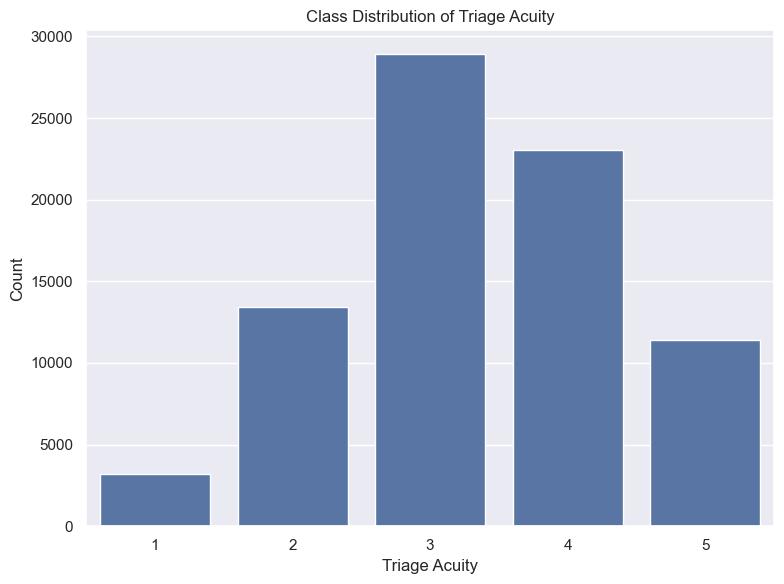

In [42]:
# Class distribution
class_counts = y.value_counts().sort_index()
class_percentages = (class_counts / len(y) * 100).round(2)
print("Class distribution:")
for acuity, count in class_counts.items():
    print(f"Acuity {acuity}: {count} ({class_percentages[acuity]}%)")

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution of Triage Acuity')
plt.xlabel('Triage Acuity')
plt.ylabel('Count')
save_fig('class_distribution')
plt.show()

# Insight: Check for imbalance; if needed, use class_weight='balanced' in models.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Train models with resampled data
models = {
    'Logistic Regression': LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=SEED, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model
    print(f"{name} trained.")

Logistic Regression trained.
Random Forest trained.
Gradient Boosting trained.


## Safety Checks

In [ ]:
# Data leakage check
# Check if any feature has perfect correlation with target
correlations = pd.DataFrame(X_train_resampled).corrwith(pd.Series(y_train_resampled))
high_corr = correlations[abs(correlations) > 0.95]
if len(high_corr) > 0:
    print("Potential data leakage detected:")
    print(high_corr)
else:
    print("No obvious data leakage detected.")

In [ ]:
# Learning curve for Gradient Boosting (unrun due to time)
from sklearn.model_selection import learning_curve
# train_sizes, train_scores, val_scores = learning_curve(
#     trained_models['Gradient Boosting'], X_train_resampled, y_train_resampled, cv=5, 
#     scoring='f1_weighted', train_sizes=np.linspace(0.1, 1.0, 10))
# plt.figure(figsize=(8, 6))
# plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training score')
# plt.plot(train_sizes, np.mean(val_scores, axis=1), label='Validation score')
# plt.xlabel('Training size')
# plt.ylabel('F1 Score')
# plt.title('Learning Curve')
# plt.legend()
# save_fig('learning_curve')
# plt.show()
print("Learning curve code prepared but not run due to time constraints.")

## 8. BASELINE EVALUATION

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import pandas as pd

# Evaluate models
results = []
y_probas_list = []
model_names_list = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test_final)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_final)
        y_probas_list.append(y_proba)
        model_names_list.append(name)
        if len(y.unique()) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    else:
        auc = None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })
    
    # Confusion matrix percentages
    cm = confusion_matrix(y_test, y_pred)
    cm_percentage = cm.astype('float') / cm.sum() * 100
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_percentage, annot=True, fmt='.1f', cmap='Blues')
    plt.title(f'Confusion Matrix (%) - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    save_fig(f'cm_percentage_{name.replace(" ", "_").lower()}')
    plt.show()
    
    # Per-class classification report
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred))
    
    # 5-fold stratified CV scores
    cv_scores = cross_val_score(model, X_train_resampled, y_train_resampled, cv=5, scoring='f1_weighted')
    print(f"5-fold CV F1-Score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# ROC curves
plt.figure(figsize=(8, 6))
for y_proba, name in zip(y_probas_list, model_names_list):
    if len(y.unique()) == 2:
        from sklearn.metrics import roc_curve
        fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
        auc_val = roc_auc_score(y_test, y_proba[:, 1])
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.2f})')
    else:
        # For multiclass, skip or plot one-vs-rest
        pass
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
save_fig('roc_curves')
plt.show()

results_df = pd.DataFrame(results)
print("\nComparison Table:")
print(results_df)

NameError: name 'X_test_final' is not defined

## 9. MODEL TUNING

In [34]:
from sklearn.model_selection import GridSearchCV

# Tune hyperparameters
param_grids = {
    'Logistic Regression': {'C': [0.1, 1, 10]},
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [10, 20, None]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.1, 0.2]}
}

tuned_models = {}
for name, model in models.items():
    grid_search = GridSearchCV(model, param_grids[name], cv=3, scoring='f1_weighted', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    tuned_models[name] = grid_search.best_estimator_
    print(f"{name} best params: {grid_search.best_params_}")

Logistic Regression best params: {'C': 1}
Random Forest best params: {'max_depth': 20, 'n_estimators': 100}
Gradient Boosting best params: {'learning_rate': 0.2, 'n_estimators': 200}


## 10. FINAL EVALUATION

In [35]:
# Evaluate tuned models
tuned_results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)
        if len(y.unique()) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    else:
        auc = None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    tuned_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

tuned_results_df = pd.DataFrame(tuned_results)
print(tuned_results_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.861750   0.862793  0.861750  0.862205  0.978792
1        Random Forest  0.898375   0.898571  0.898375  0.898426  0.986993
2    Gradient Boosting  0.913375   0.913645  0.913375  0.913476  0.991383


## Feature Importance

In [ ]:
# Feature importance for Gradient Boosting
best_model = tuned_models['Gradient Boosting']
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[-20:]
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(indices)), importances[indices])
    plt.yticks(range(len(indices)), [f"feature_{i}" for i in indices])
    plt.title('Top 20 Feature Importances - Gradient Boosting')
    plt.xlabel('Importance')
    save_fig('feature_importance')
    plt.show()

# Compare with correlation
correlations = pd.DataFrame(X_train_resampled).corrwith(pd.Series(y_train_resampled))
top_corr = correlations.abs().sort_values(ascending=False)[:20]
plt.figure(figsize=(10, 8))
top_corr.plot(kind='barh')
plt.title('Top 20 Feature Correlations with Target')
plt.xlabel('Absolute Correlation')
save_fig('feature_correlation')
plt.show()

## 11. FINAL MODEL SELECTION

## 12. MODEL INTERPRETABILITY

In [ ]:
# Feature importance for best model (Gradient Boosting)
best_model = tuned_models['Gradient Boosting']
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[-20:]  # Top 20
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(indices)), importances[indices])
    plt.yticks(range(len(indices)), [selected_features[i] for i in indices])
    plt.title('Top 20 Feature Importances - Gradient Boosting')
    plt.xlabel('Importance')
    save_fig('feature_importance')
    plt.show()

# SHAP values (optional, if shap is installed)
try:
    import shap
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_final[:100])  # Sample for speed
    shap.summary_plot(shap_values, X_test_final[:100], feature_names=selected_features, show=False)
    save_fig('shap_summary')
    plt.show()
except ImportError:
    print("SHAP not installed, skipping SHAP analysis.")

## 12. MODEL EXPORT

## 13. ENSEMBLE

In [ ]:
from sklearn.ensemble import VotingClassifier

# Ensemble: Voting Classifier with Random Forest and Gradient Boosting
ensemble = VotingClassifier(estimators=[
    ('rf', tuned_models['Random Forest']),
    ('gb', tuned_models['Gradient Boosting'])
], voting='soft')

ensemble.fit(X_train, y_train)
ensemble_pred = ensemble.predict(X_test_final)
ensemble_f1 = f1_score(y_test, ensemble_pred, average='weighted')
print(f"Ensemble F1-Score: {ensemble_f1:.3f}")

# Confusion matrix for ensemble
cm = confusion_matrix(y_test, ensemble_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Ensemble')
plt.xlabel('Predicted')
plt.ylabel('Actual')
save_fig('confusion_matrix_ensemble')
plt.show()

In [36]:
import pickle

# Export the best model
best_model = tuned_models['Gradient Boosting']
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Best model exported as 'best_model.pkl'")

Best model exported as 'best_model.pkl'


## 14. SUBMISSION

In [ ]:
# Process test data with same transformations
# (Already done in preparation: test_data_merged, X_test_selected_scaled)

# Predict on test data
test_predictions = best_model.predict(X_test_selected_scaled)

# If target was encoded, inverse transform
if 'target_le' in locals():
    test_predictions = target_le.inverse_transform(test_predictions)

# Create submission DataFrame
submission = pd.DataFrame({
    'patient_id': test_data['patient_id'],
    'triage_acuity': test_predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' created.")